# Carga de datos y exploracion inicial

In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

### Leyendo datos de dataset

In [6]:
df = pd.read_csv('Data_Merma.csv', sep=';')

print("Dataset cargado correctamente.")
df.head(3)

Dataset cargado correctamente.


,fecha,turno,categoria,maquina,gramaje,ancho,peso_kg,metros_lineales,arranque,rangos,ajustes_de_maquina,merma_kg,merma_mts
0,23/01/2026,A,BOPP/COEX/,SUPER SIMPLEX,70.08,710.0,502,12989.0,14.8,0.0,0.0,14.8,297.45
1,23/01/2026,A,BOPP/COEX/,SUPER SIMPLEX,70.08,710.0,418,10851.0,5.2,0.0,0.0,5.2,104.51
2,23/01/2026,A,BOPP/Metalizado/,SUPER SIMPLEX,31.60,1080.0,2806,74121.0,36.5,0.0,0.0,36.5,1069.50


In [7]:
df.shape

(267, 13)

In [8]:
df.dtypes

fecha                     str
turno                     str
categoria                 str
maquina                   str
gramaje               float64
ancho                 float64
peso_kg                 int64
metros_lineales       float64
arranque              float64
rangos                float64
ajustes_de_maquina    float64
merma_kg              float64
merma_mts             float64
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               267 non-null    str    
 1   turno               267 non-null    str    
 2   categoria           267 non-null    str    
 3   maquina             267 non-null    str    
 4   gramaje             263 non-null    float64
 5   ancho               263 non-null    float64
 6   peso_kg             267 non-null    int64  
 7   metros_lineales     266 non-null    float64
 8   arranque            267 non-null    float64
 9   rangos              267 non-null    float64
 10  ajustes_de_maquina  267 non-null    float64
 11  merma_kg            267 non-null    float64
 12  merma_mts           267 non-null    float64
dtypes: float64(8), int64(1), str(4)
memory usage: 27.2 KB


In [10]:
df.describe()

,gramaje,ancho,peso_kg,metros_lineales,arranque,rangos,ajustes_de_maquina,merma_kg,merma_mts
count,263.000000,263.000000,267.000000,266.000000,267.000000,267.000000,267.000000,267.000000,267.000000
mean,49.900000,933.422053,1457.655431,38228.571429,21.374157,1.322097,1.125843,23.822097,593.265206
std,23.853305,155.552747,1158.662601,33302.546275,13.930778,5.346561,5.405209,14.827532,408.841754
min,27.200000,510.000000,9.000000,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.600000,860.000000,518.500000,12923.000000,11.000000,0.000000,0.000000,12.500000,289.685000
50%,36.400000,910.000000,1116.000000,28584.500000,18.000000,0.000000,0.000000,20.000000,501.560000
75%,64.440000,1080.000000,2242.000000,57900.500000,28.000000,0.000000,0.000000,34.000000,808.935000
max,133.970000,1250.000000,4791.000000,128783.000000,82.000000,35.000000,46.000000,82.000000,2391.000000


In [11]:
df.isnull().sum().sort_values(ascending=False)

gramaje               4
ancho                 4
metros_lineales       1
fecha                 0
turno                 0
maquina               0
categoria             0
peso_kg               0
arranque              0
rangos                0
ajustes_de_maquina    0
merma_kg              0
merma_mts             0
dtype: int64

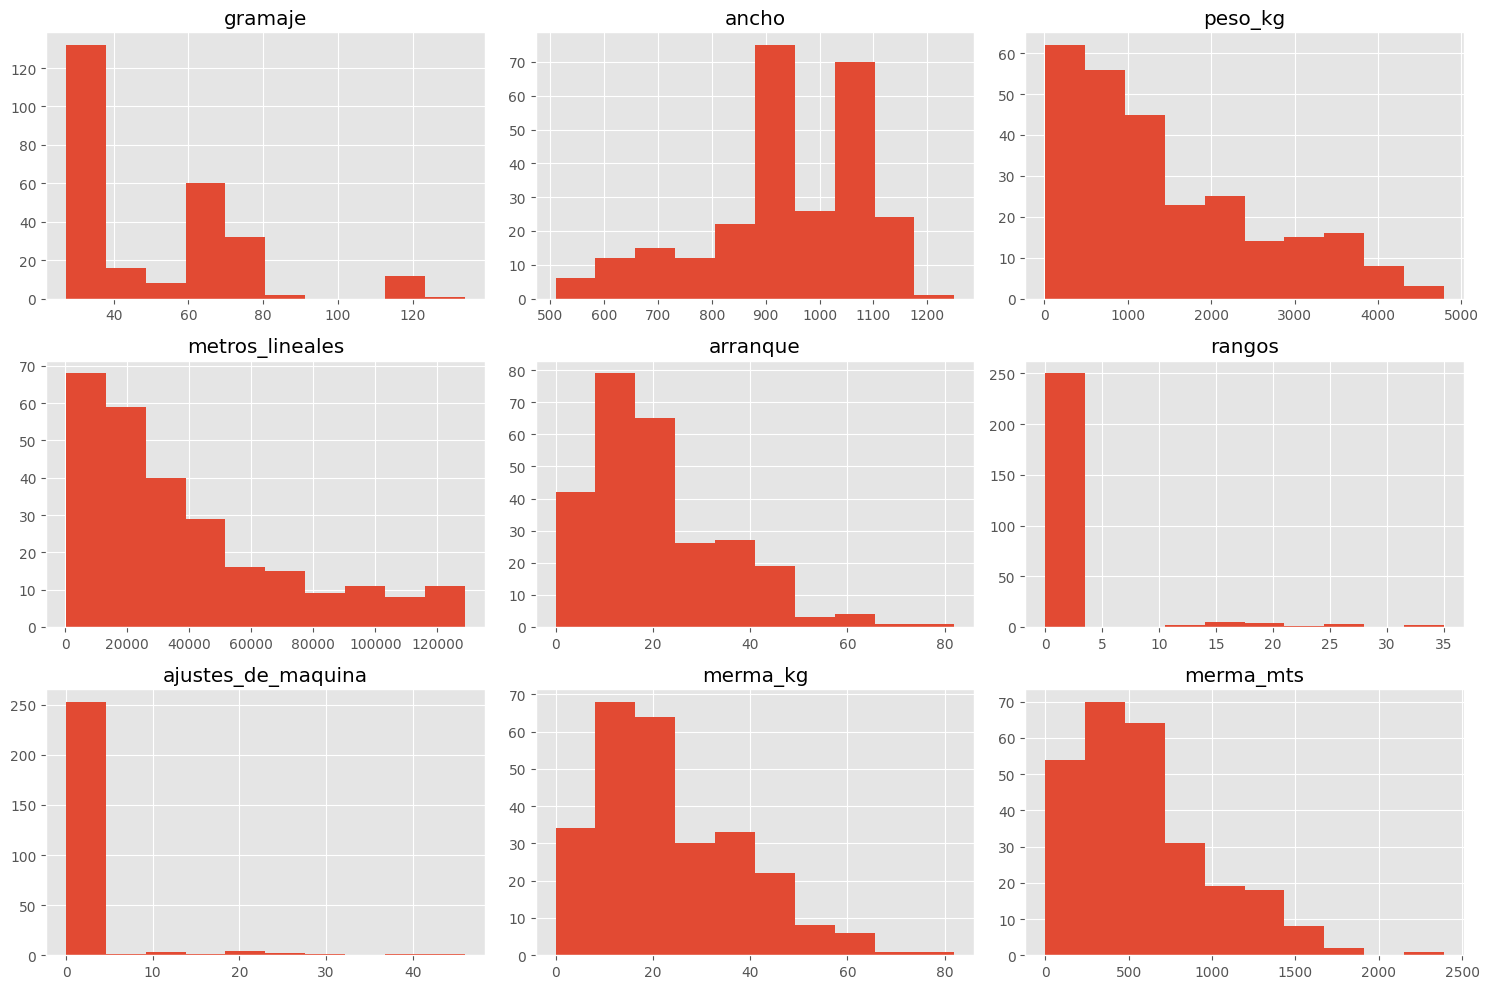

In [12]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [13]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.head(3) 

,gramaje,ancho,peso_kg,metros_lineales,arranque,rangos,ajustes_de_maquina,merma_kg,merma_mts
0,70.08,710.0,502,12989.0,14.8,0.0,0.0,14.8,297.45
1,70.08,710.0,418,10851.0,5.2,0.0,0.0,5.2,104.51
2,31.60,1080.0,2806,74121.0,36.5,0.0,0.0,36.5,1069.50


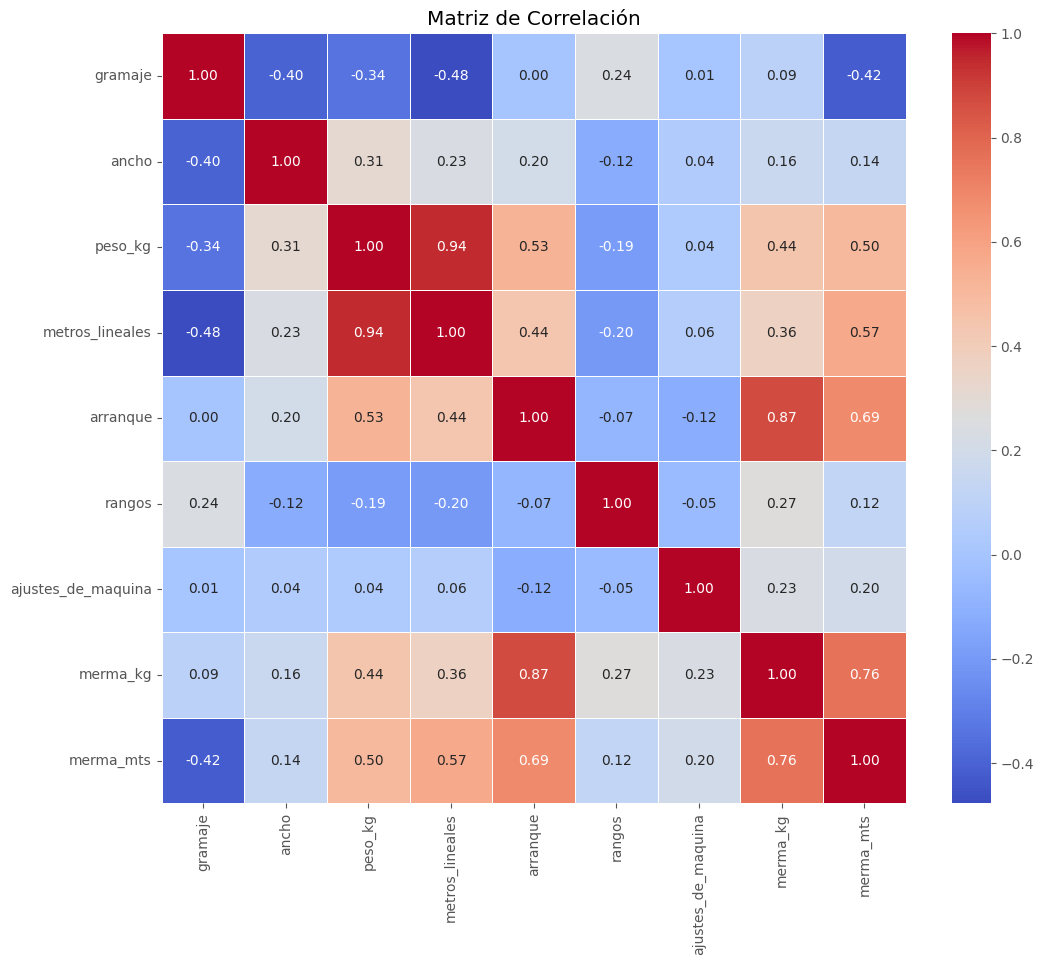

In [14]:
corr_matrix = df_numeric.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

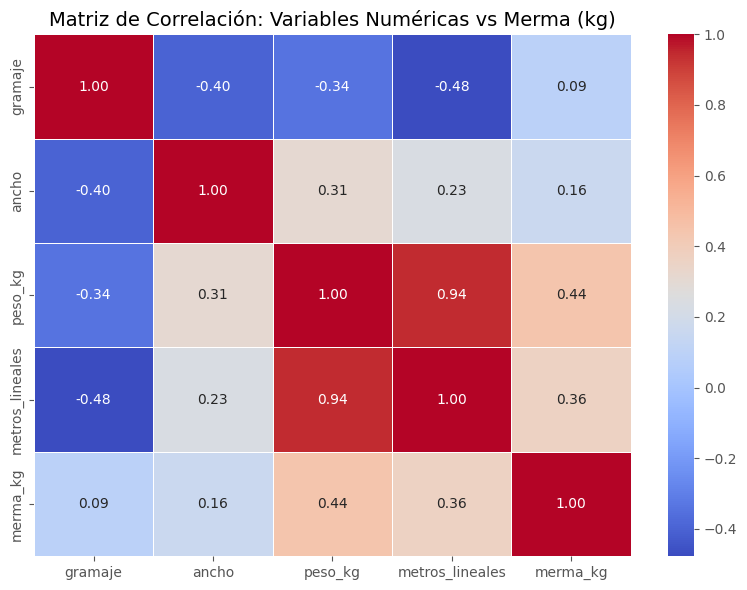

In [ ]:
columnas_numericas = ['gramaje', 'ancho', 'peso_kg', 'metros_lineales', 'merma_kg']
df_analisis = df[columnas_numericas]

matriz_correlacion = df_analisis.corr()

plt.figure(figsize=(8, 6)) 
sns.heatmap(matriz_correlacion, 
            annot=True,          
            cmap='coolwarm',     
            fmt=".2f",           
            linewidths=0.5)      

plt.title('Matriz de Correlación: Variables Numéricas vs Merma (kg)', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\dguer\AppData\Local\Temp\ipykernel_22008\905855229.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="viridis")


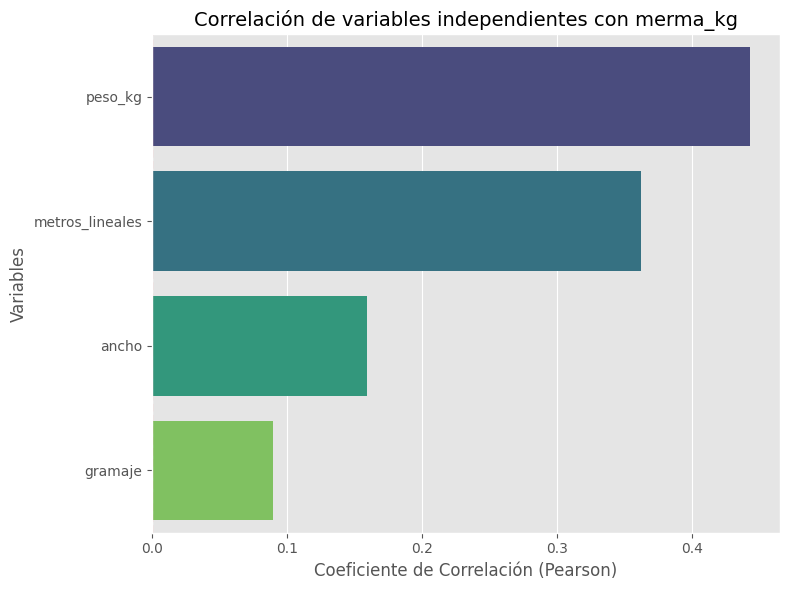

In [ ]:

objetivo = 'merma_kg'
y= df_analisis[objetivo]
X = df_analisis.drop(columns=[objetivo], errors="ignore")
corr_target = df_analisis.corr()[objetivo].drop(objetivo).sort_values(ascending=False)

# 2. Visualización
plt.figure(figsize=(8,6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette="viridis")

plt.title(f"Correlación de variables independientes con {objetivo}", fontsize=14)
plt.xlabel("Coeficiente de Correlación (Pearson)", fontsize=12)
plt.ylabel("Variables", fontsize=12)

plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

C:\Users\dguer\AppData\Local\Temp\ipykernel_22008\1333175994.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=columna_estructura, y=columna_merma, palette='viridis')


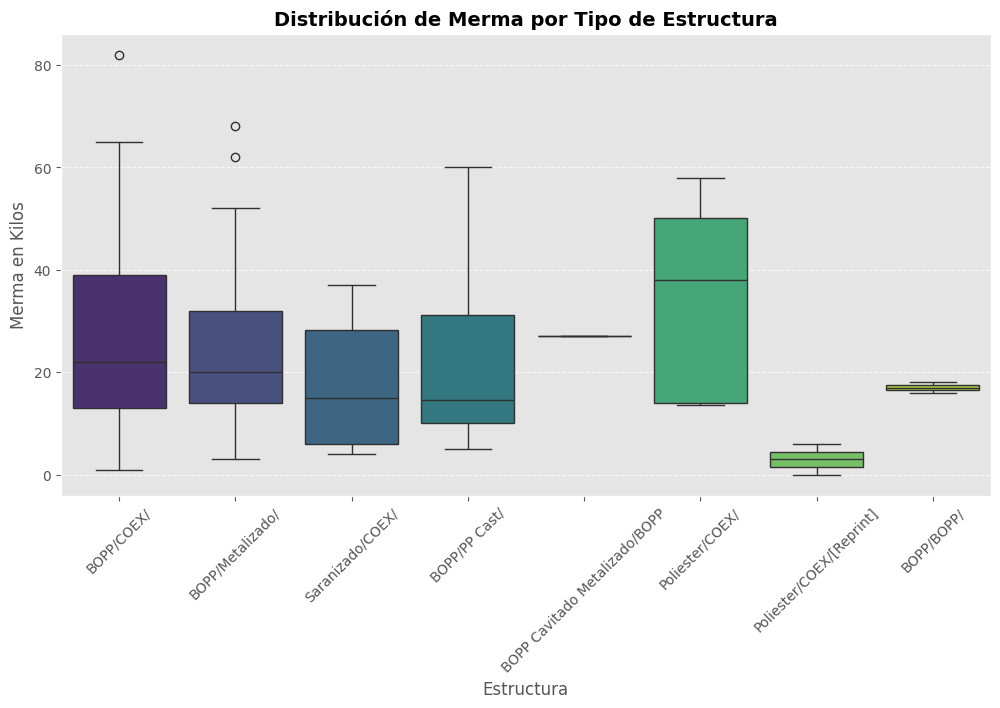

C:\Users\dguer\AppData\Local\Temp\ipykernel_22008\1333175994.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=columna_estructura, y=columna_merma, estimator='mean', palette='viridis')


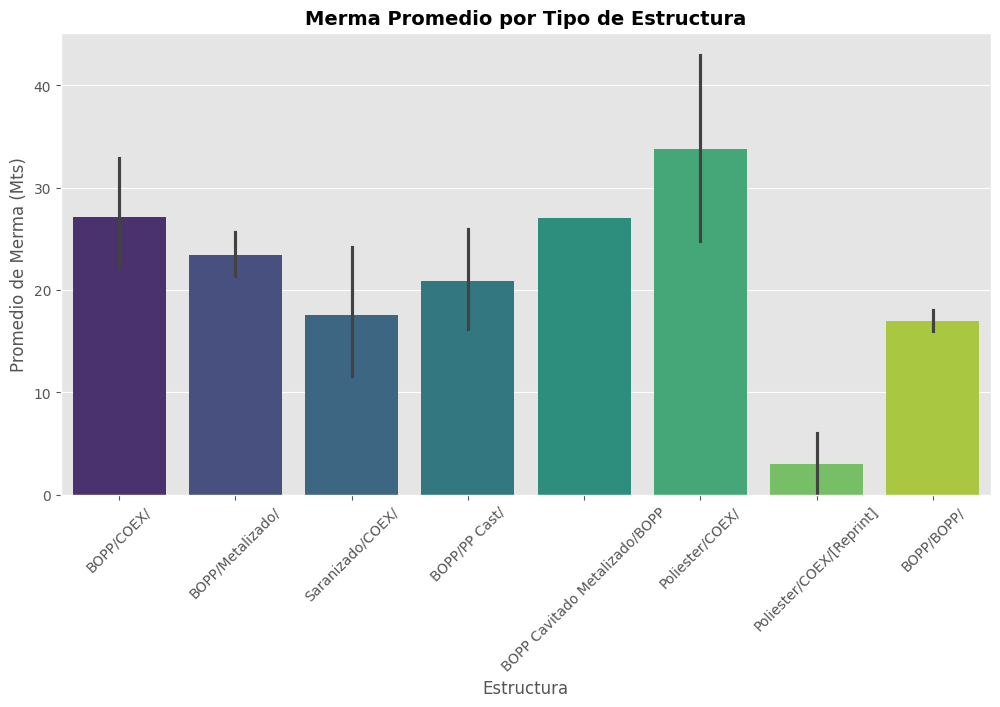

C:\Users\dguer\AppData\Local\Temp\ipykernel_22008\1333175994.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=columna_estructura, palette='viridis')


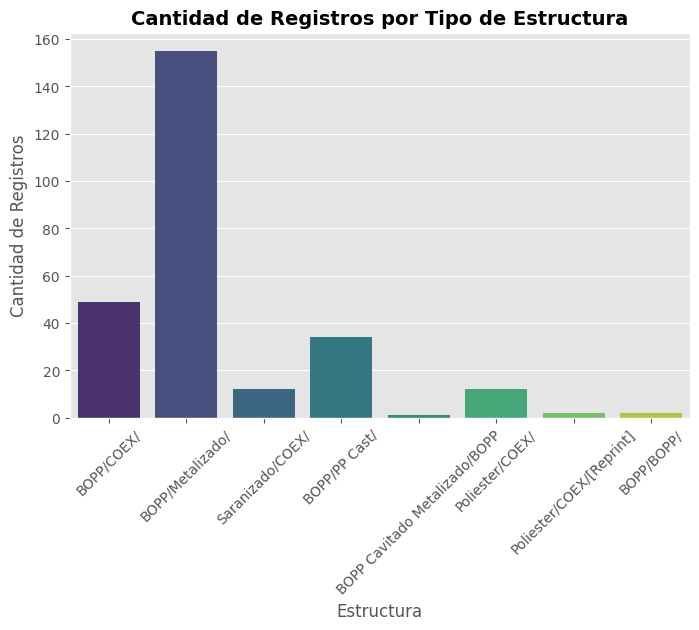

In [33]:
columna_estructura = 'categoria' 
columna_merma = 'merma_kg'  

# GRÁFICO 1: BOXPLOT (Para ver la variación y valores atípicos)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x=columna_estructura, y=columna_merma, palette='viridis')

plt.title('Distribución de Merma por Tipo de Estructura', fontsize=14, fontweight='bold')
plt.xlabel('Estructura', fontsize=12)
plt.ylabel('Merma en Kilos', fontsize=12)
plt.xticks(rotation=45) # Giramos los nombres 45 grados por si son muy largos
plt.grid(axis='y', linestyle='--', alpha=0.7) # Agregamos una cuadrícula de fondo
plt.show()

# GRÁFICO 2: BARPLOT (Para ver el promedio claro)

plt.figure(figsize=(12, 6))
# estimator='mean' hace que la barra muestre el promedio
sns.barplot(data=df, x=columna_estructura, y=columna_merma, estimator='mean', palette='viridis')

plt.title('Merma Promedio por Tipo de Estructura', fontsize=14, fontweight='bold')
plt.xlabel('Estructura', fontsize=12)
plt.ylabel('Promedio de Merma (Mts)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x=columna_estructura, palette='viridis')
plt.title('Cantidad de Registros por Tipo de Estructura', fontsize=14, fontweight='bold')
plt.xlabel('Estructura', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# División de datos

In [31]:
from sklearn.model_selection import train_test_split
columnas_modelo = ['fecha', 'turno', 'categoria', 'maquina', 'gramaje', 'ancho', 'peso_kg', 'metros_lineales', 'merma_kg']
df_modelo = df[columnas_modelo]

X = df_modelo.drop(columns=['merma_kg'], errors='ignore')
y = df_modelo['merma_kg']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=7833
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (213, 8)
X_test: (54, 8)
y_train: (213,)
y_test: (54,)


In [32]:
import os

# 1. Quitamos la diagonal inicial para que se cree en tu carpeta actual
os.makedirs("processed", exist_ok=True)

# 2. Copiamos los datos de entrenamiento
train_df = X_train.copy()
train_df["MERMA_Kg"] = y_train  # Le ponemos un nombre más acorde a tu proyecto

# 3. Copiamos los datos de prueba
test_df = X_test.copy()
test_df["MERMA_Kg"] = y_test

# 4. Guardamos los archivos (igual, sin la diagonal al inicio)
train_df.to_csv("processed/train.csv", index=False)
test_df.to_csv("processed/test.csv", index=False)

print("¡Archivos guardados correctamente en la carpeta 'processed' de tu directorio actual!")

¡Archivos guardados correctamente en la carpeta 'processed' de tu directorio actual!
